<a href="https://colab.research.google.com/github/SalmaAnindhia/PCVK26_25_Salma/blob/main/P6_Tugas_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
NAMA = 'Salma Nur Anindhia'
NIM = '244107020186'
print(NAMA, NIM)

Salma Nur Anindhia 244107020186


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image

In [4]:
def convolution2d(image, kernel, stride=1, padding=0):
    if padding > 0:
        image_padded = np.pad(image, padding, mode='constant', constant_values=0)
    else:
        image_padded = image

    kernel_height, kernel_width = kernel.shape
    image_height, image_width = image_padded.shape

    out_height = ((image_height - kernel_height) // stride) + 1
    out_width = ((image_width - kernel_width) // stride) + 1

    output = np.zeros((out_height, out_width))

    for y in range(0, out_height):
        for x in range(0, out_width):
            region = image_padded[y*stride:y*stride+kernel_height, x*stride:x*stride+kernel_width]
            output[y, x] = np.sum(region * kernel)

    return output

In [5]:
BASE =  '/content/drive/MyDrive/MATKUL BU HANI/KTM/'

In [6]:
img = cv.imread(BASE + 'mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

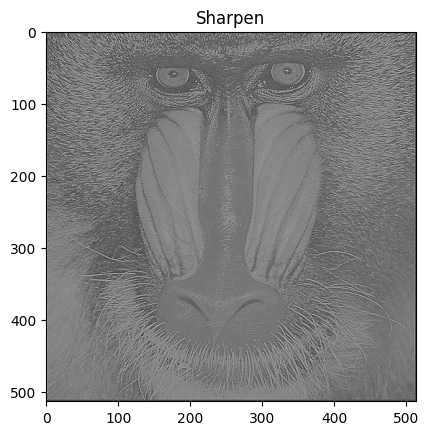

In [7]:
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])
hasil = convolution2d(img_gray, kernel_sharpen, 1, 2)
plt.imshow(hasil, cmap='gray')
plt.title('Sharpen')
plt.show()

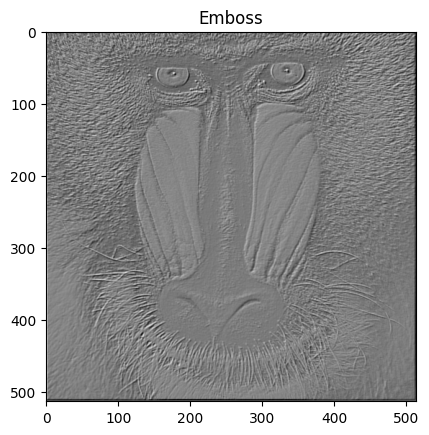

In [8]:
kernel_emboss = np.array([[-2,-1,0],
                          [-1,1,1],
                          [0,1,2]])
hasil = convolution2d(img_gray, kernel_emboss, 1, 2)
plt.imshow(hasil, cmap='gray')
plt.title('Emboss')
plt.show()

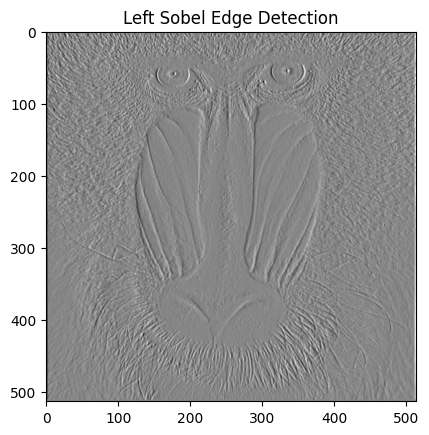

In [9]:
kernel_sobel = np.array([[1,0,-1],
                         [2,0,-2],
                         [1,0,-1]])
hasil = convolution2d(img_gray, kernel_sobel, 1, 2)
plt.imshow(hasil, cmap='gray')
plt.title('Left Sobel Edge Detection')
plt.show()

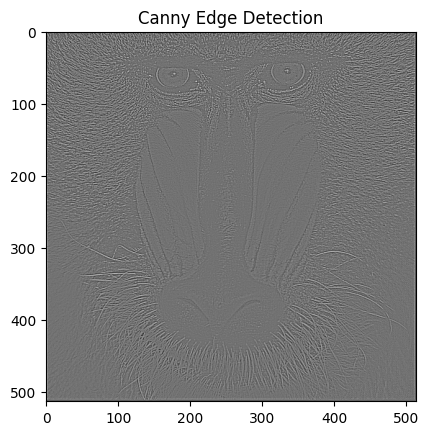

In [10]:
kernel_canny = np.array([[-1,-1,-1],
                         [-1,8,-1],
                         [-1,-1,-1]])
hasil = convolution2d(img_gray, kernel_canny, 1, 2)
plt.imshow(hasil, cmap='gray')
plt.title('Canny Edge Detection')
plt.show()

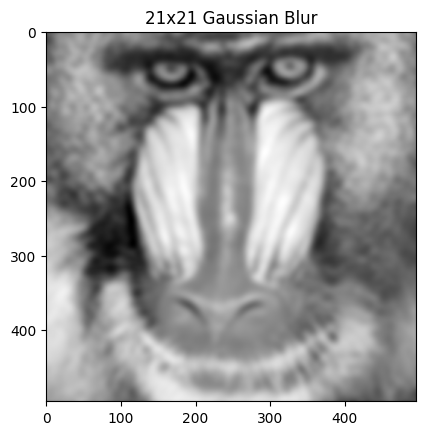

In [11]:
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()
hasil = convolution2d(img_gray, gauss_kernel, 1, 2)
plt.imshow(hasil, cmap='gray')
plt.title('21x21 Gaussian Blur')
plt.show()

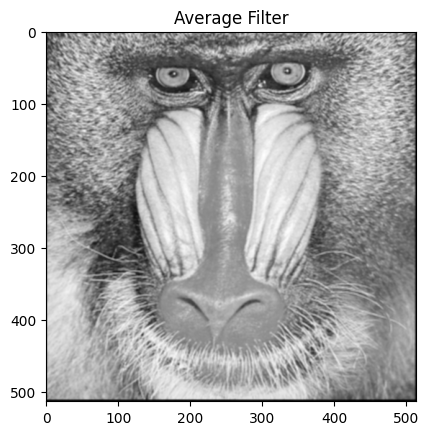

In [12]:
kernel_average = np.ones((3,3)) / 9
hasil = convolution2d(img_gray, kernel_average, 1, 2)
plt.imshow(hasil, cmap='gray')
plt.title('Average Filter')
plt.show()

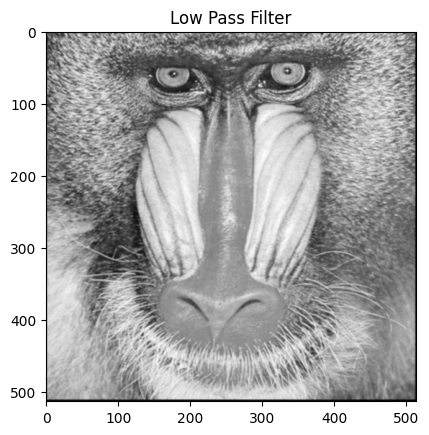

In [13]:
kernel_lowpass = np.array([[1,1,1],
                           [1,4,1],
                           [1,1,1]]) / 12
hasil = convolution2d(img_gray, kernel_lowpass, 1, 2)
plt.imshow(hasil, cmap='gray')
plt.title('Low Pass Filter')
plt.show()

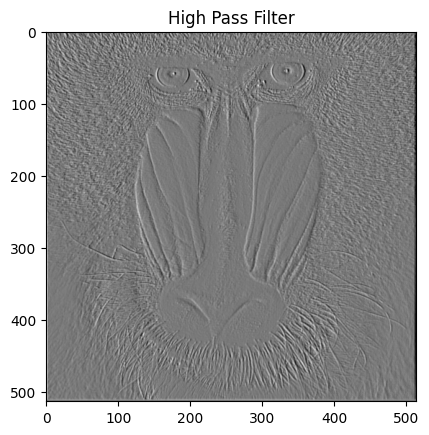

In [14]:
kernel_highpass = np.array([[-1,0,1],
                            [-1,0,3],
                            [-3,0,1]])
hasil = convolution2d(img_gray, kernel_highpass, 1, 2)
plt.imshow(hasil, cmap='gray')
plt.title('High Pass Filter')
plt.show()

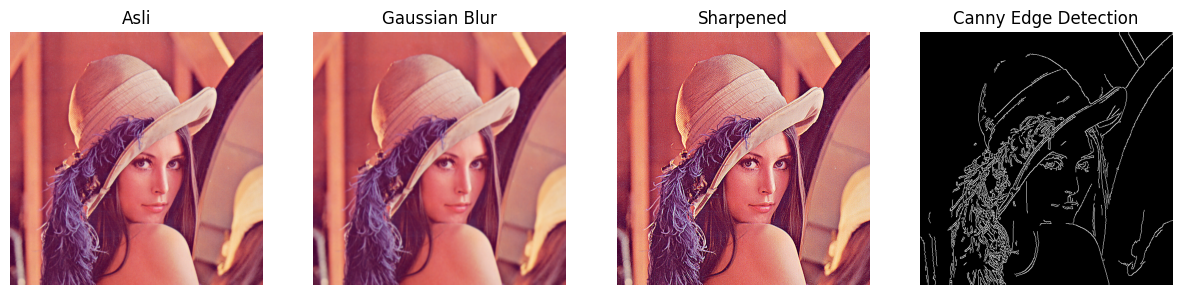

In [15]:
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread(BASE + 'lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

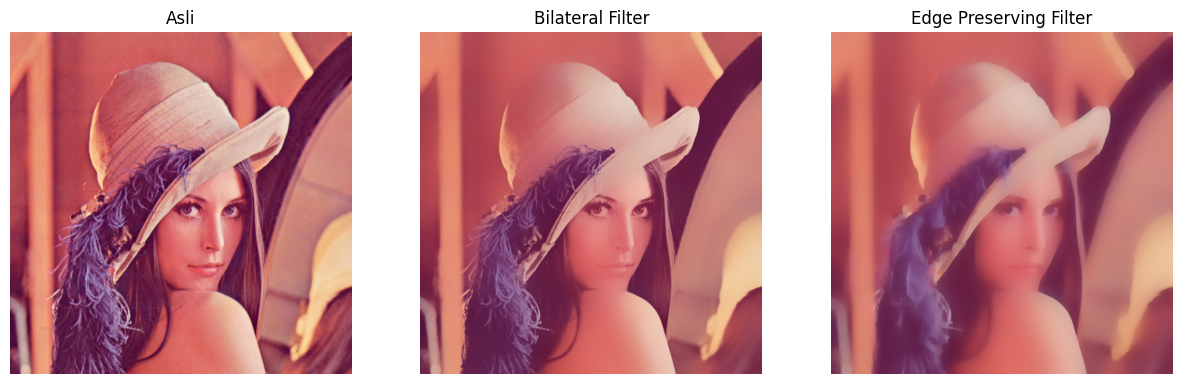

In [16]:
bilateral = cv.bilateralFilter(img, 50, 100, 100)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

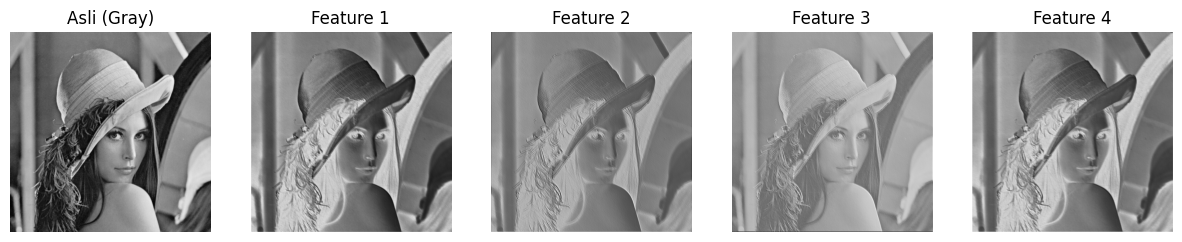

In [17]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

with torch.no_grad():
    features = model(img_tensor)

feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

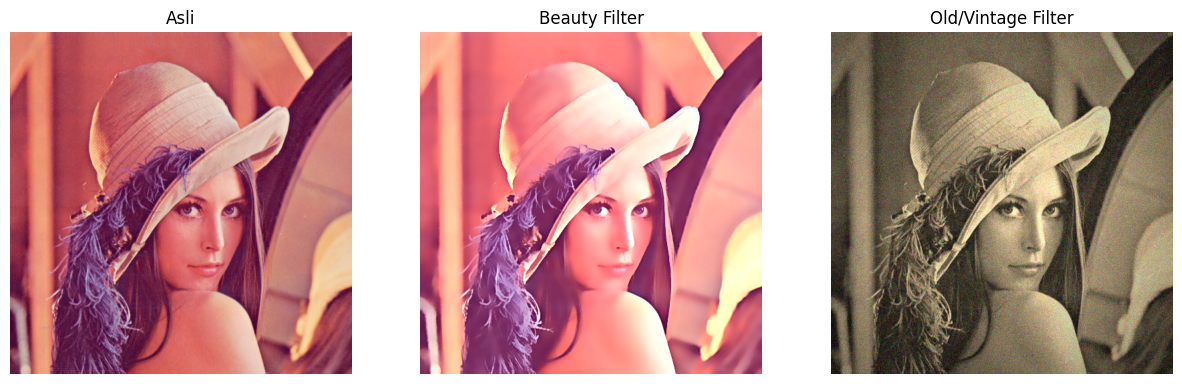

In [19]:
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

alpha = 1.2
beta = 15
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

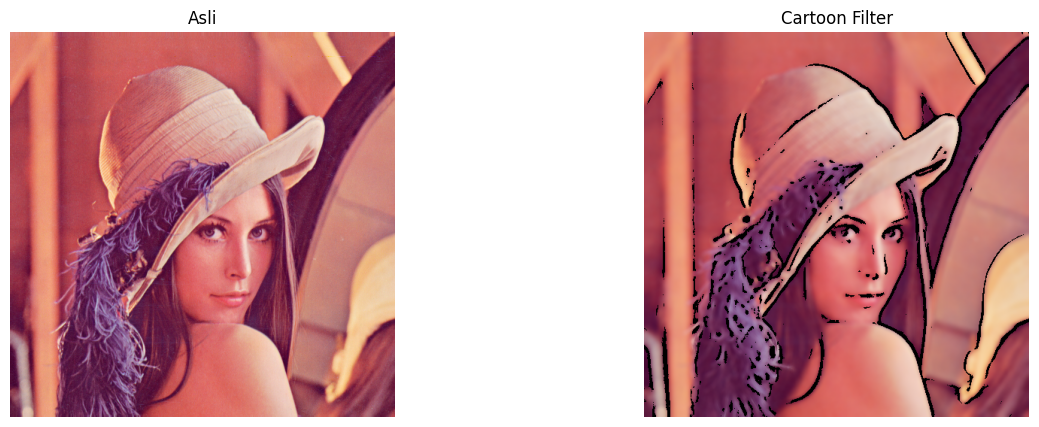

In [20]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)
cartoon = cv.bitwise_and(color, color, mask=edges)
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

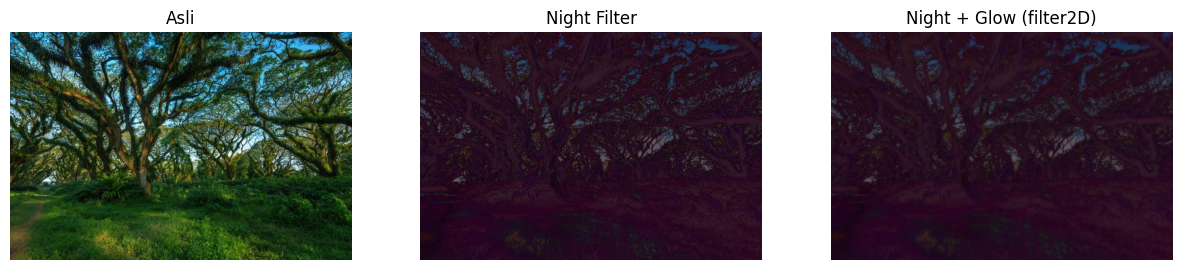

In [21]:
img = cv.imread(BASE + 'djawatan.jpg')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

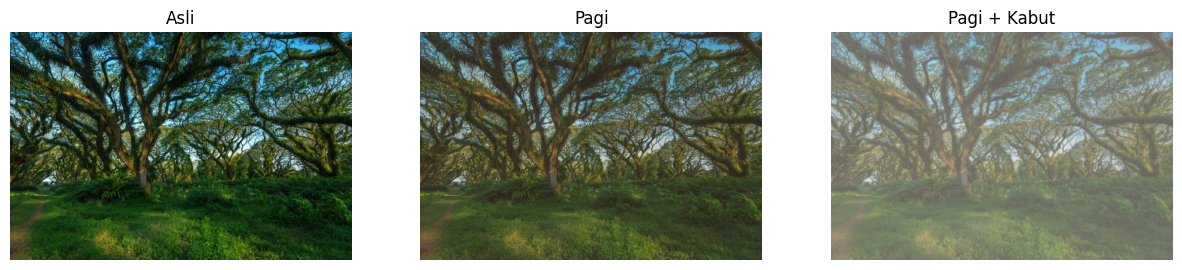

In [22]:
alpha = 0.9
beta = 20
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

warm_tint = np.full_like(soft, (40, 70, 120))
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T
kabut = cv.filter2D(pagi, -1, kernel)

white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

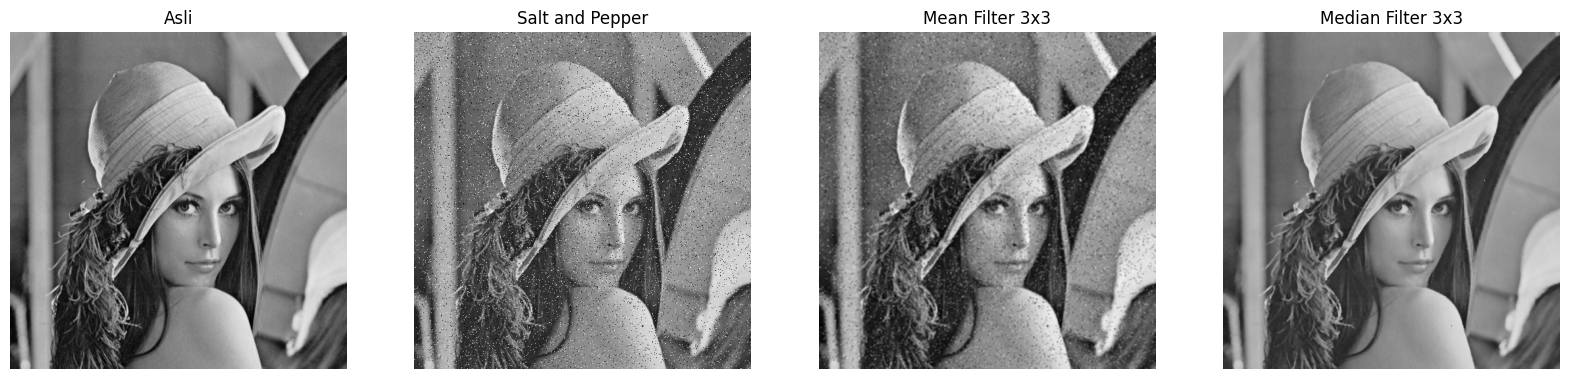

In [23]:
img = cv.imread(BASE + 'lena.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

noisy = gray.copy()
rnd = np.random.rand(*gray.shape)
noisy[rnd < 0.025] = 0
noisy[rnd > 0.975] = 255

mean_filter = cv.blur(noisy, (3,3))
median_filter = cv.medianBlur(noisy, 3)

show_side_by_side([gray, noisy, mean_filter, median_filter],
                  ["Asli", "Salt and Pepper", "Mean Filter 3x3", "Median Filter 3x3"],
                  figsize=(20,5))

Mean Filter: Piksel noise 0/255 ikut masuk ke rata-rata, jadi nilainya tidak hilang, hanya menyebar ke tetangga. Hasilnya muncul bercak abu-abu dan tepi jadi kabur.

Median Filter: 9 nilai di jendela 3x3 diurutkan, lalu diambil nilai tengahnya. Nilai noise yang ekstrem berada di ujung urutan sehingga tidak terpilih, dan piksel noise diganti dengan nilai tetangganya.

Jadi median Filter lebih bersih untuk noise Salt and Pepper karena membuang noise, bukan menyebarkannya.

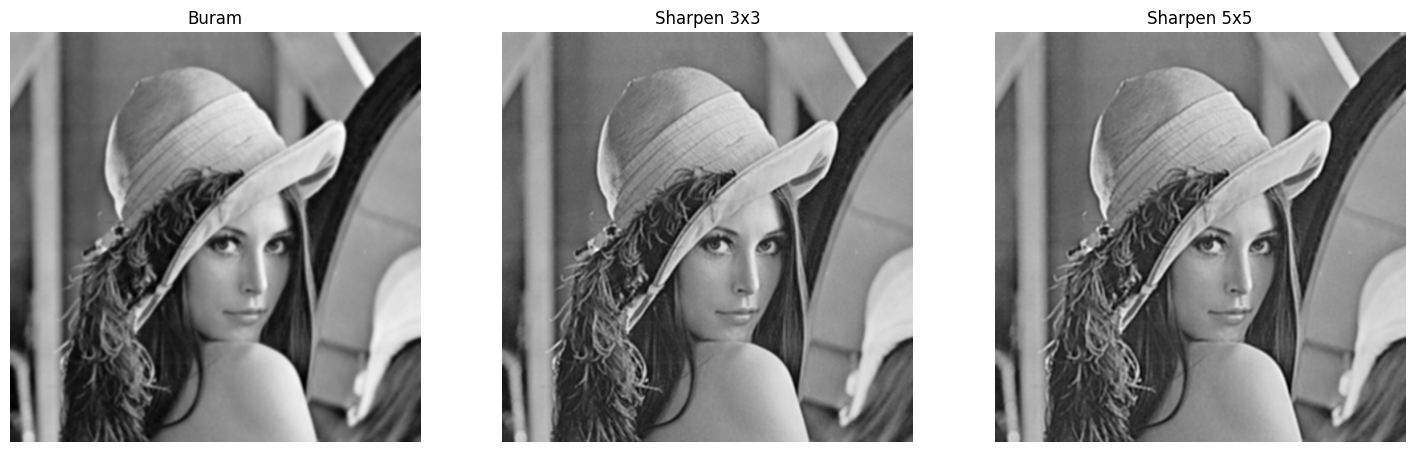

In [24]:
kernel_3x3 = np.array([[0,-1,0],
                       [-1,5,-1],
                       [0,-1,0]])

kernel_5x5 = np.array([[-1,-1,-1,-1,-1],
                       [-1,2,2,2,-1],
                       [-1,2,8,2,-1],
                       [-1,2,2,2,-1],
                       [-1,-1,-1,-1,-1]]) / 8

blurry = cv.GaussianBlur(gray, (5,5), 1.5)
sharp_3x3 = cv.filter2D(blurry, -1, kernel_3x3)
sharp_5x5 = cv.filter2D(blurry, -1, kernel_5x5)

show_side_by_side([blurry, sharp_3x3, sharp_5x5],
                  ["Buram", "Sharpen 3x3", "Sharpen 5x5"], figsize=(18,6))

Kedua kernel berhasil menajamkan gambar buram tekstur rambut, pita topi, dan tepi topi jadi lebih jelas. Kernel 5x5 memberi penajaman lebih kuat, tetapi tekstur tampak lebih kasar. Untuk kernel 3x3 hasilnya lebih natural dan komputasinya lebih ringan, dan cocok untuk penggunaan sehari-hari karna lebih optimal karena cukup tajam dan efisien

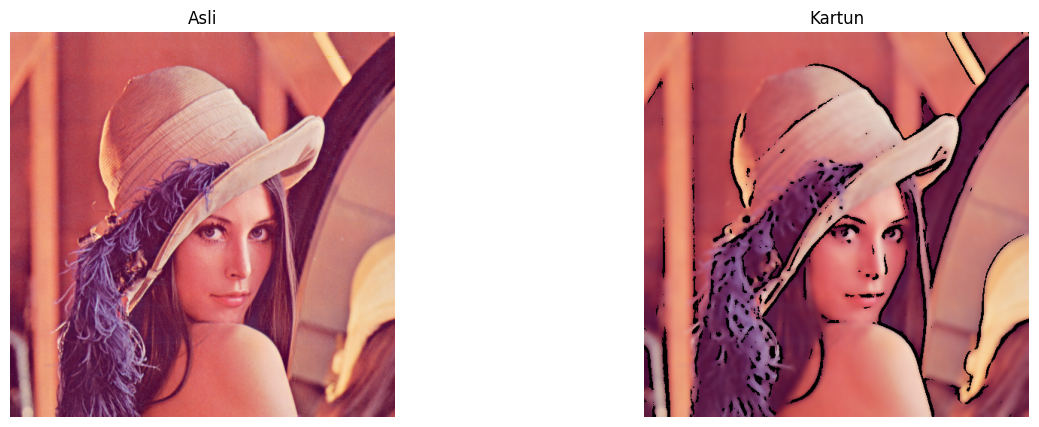

In [25]:
def kartun(image):
    warna = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    tepi = cv.adaptiveThreshold(gray_blur, 255,
                                cv.ADAPTIVE_THRESH_MEAN_C,
                                cv.THRESH_BINARY, 9, 9)

    return cv.bitwise_and(warna, warna, mask=tepi)

hasil_kartun = kartun(img)
show_side_by_side([img, hasil_kartun], ["Asli", "Kartun"])